# 1. Imports
Semua library yang dibutuhkan dikonsolidasi dalam satu sel.

In [1]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet50_Weights

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

# 2. Data Preparation
Mengunduh dataset dari Kaggle menggunakan `kagglehub` dan menyiapkan path train, valid, dan test yang sudah tersedia.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
print("Path to dataset files:", path)

dataset_path = path
data_dir     = Path(dataset_path)

# Dataset sudah memiliki struktur Data/train, Data/valid, Data/test
base_dir   = os.path.join(dataset_path, "Data")
TRAIN_PATH = os.path.join(base_dir, "train")
VAL_PATH   = os.path.join(base_dir, "valid")
TEST_PATH  = os.path.join(base_dir, "test")

BATCH_SIZE = 32
IMG_SIZE   = (460, 460)

print("Train :", TRAIN_PATH)
print("Valid :", VAL_PATH)
print("Test  :", TEST_PATH)

# Verifikasi jumlah gambar per kelas
for label, pth in [("TRAIN", TRAIN_PATH), ("VAL", VAL_PATH), ("TEST", TEST_PATH)]:
    print(f"\n[{label}]")
    for cls in sorted(os.listdir(pth)):
        cls_path = os.path.join(pth, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
            print(f"  {cls}: {n} gambar")

# Class names dari folder train (nama folder lengkap)
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
print("\nKelas (train):", CLASS_NAMES)

Path to dataset files: /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images
Train : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train
Valid : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/valid
Test  : /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/test

[TRAIN]
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195 gambar
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115 gambar
  normal: 148 gambar
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155 gambar

[VAL]
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 gambar
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 gambar
  normal: 13 gambar
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 gambar

[TEST]
  adenocarcinoma: 120 gambar
  large.cell.carcinoma: 51 gambar
  normal: 54 gambar
  squamous.cell.carcinoma: 90 gambar

Kelas (train): ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left

## Visualisasi 1 — Distribusi Dataset per Kelas
Menampilkan jumlah gambar pada setiap split (Train / Validasi / Test) untuk masing-masing kelas.

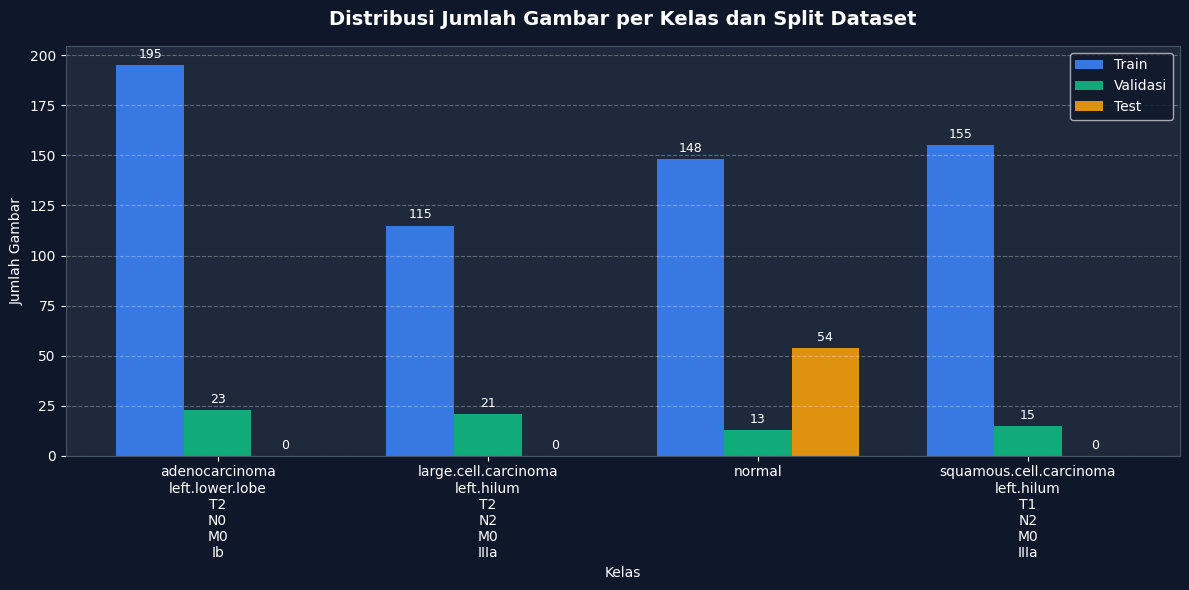

Gambar disimpan: viz_dataset_distribution.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

splits = {"Train": TRAIN_PATH, "Validasi": VAL_PATH, "Test": TEST_PATH}
split_counts = {}

for split_name, path in splits.items():
    counts = {}
    if os.path.isdir(path):
        for cls in CLASS_NAMES:
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                counts[cls] = len([f for f in os.listdir(cls_path)
                                   if os.path.isfile(os.path.join(cls_path, f))])
            else:
                counts[cls] = 0
    split_counts[split_name] = counts

x = np.arange(len(CLASS_NAMES))
width = 0.25
colors = ["#3b82f6", "#10b981", "#f59e0b"]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

for i, (split_name, color) in enumerate(zip(splits.keys(), colors)):
    vals = [split_counts[split_name].get(cls, 0) for cls in CLASS_NAMES]
    bars = ax.bar(x + i * width, vals, width, label=split_name, color=color, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=9, color="white")

short_names = [cls.replace("_", "\n") for cls in CLASS_NAMES]
ax.set_xticks(x + width)
ax.set_xticklabels(short_names, color="white", fontsize=10)
ax.set_title("Distribusi Jumlah Gambar per Kelas dan Split Dataset", fontsize=14,
             fontweight="bold", color="white", pad=15)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_dataset_distribution.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Gambar disimpan: viz_dataset_distribution.png")


## Visualisasi 2 — Contoh Gambar CT-Scan per Kelas
Menampilkan 3 sampel gambar dari masing-masing kelas dalam dataset train.

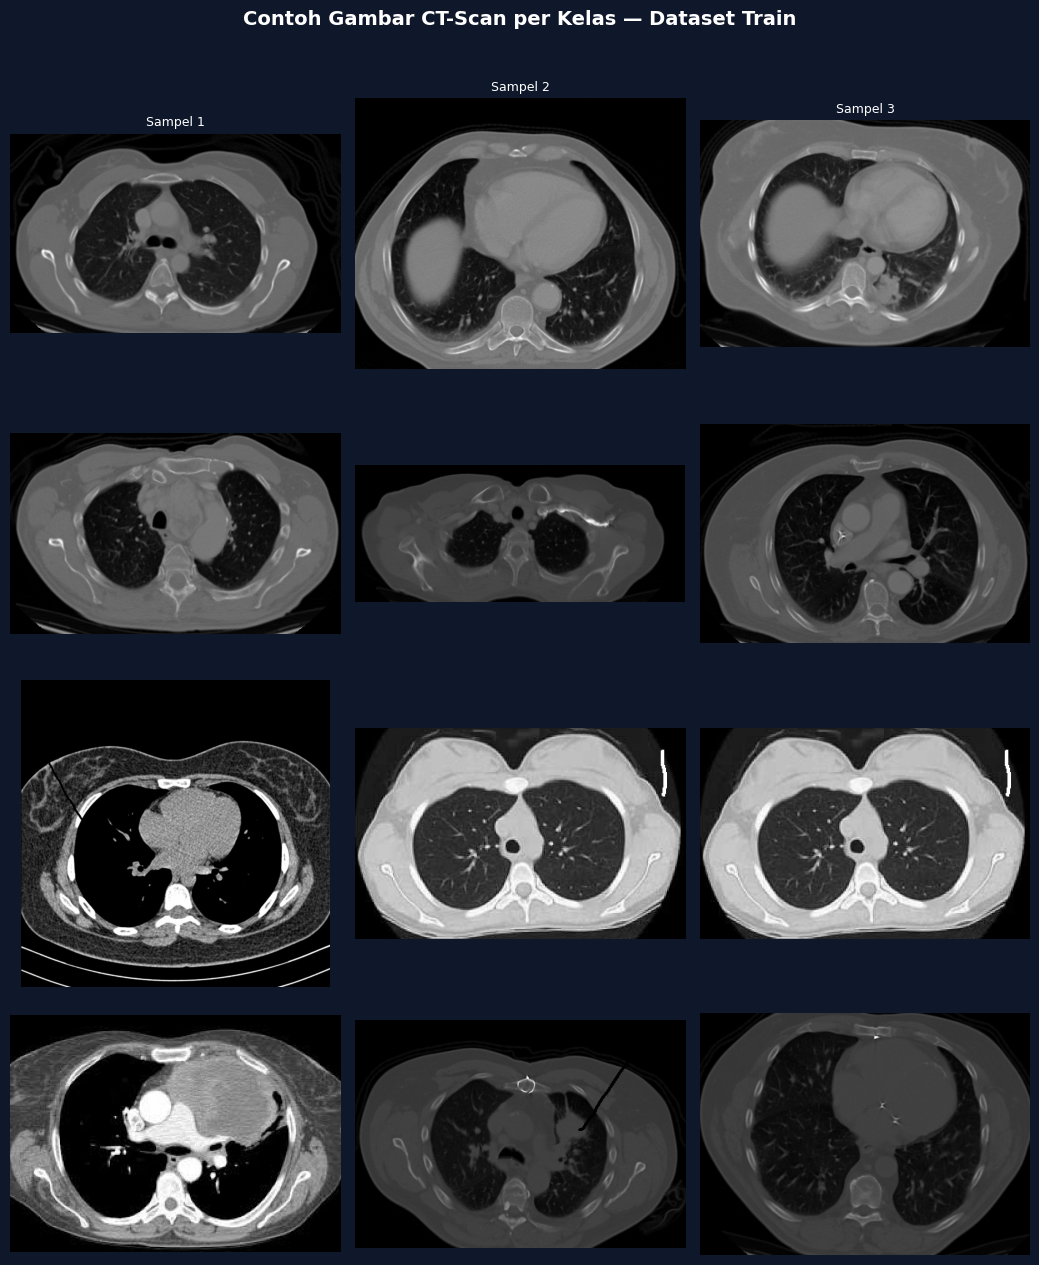

Gambar disimpan: viz_sample_images.png


In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import os, random

N_SAMPLES = 3
fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLES,
                         figsize=(N_SAMPLES * 3.5, len(CLASS_NAMES) * 3.2))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Contoh Gambar CT-Scan per Kelas — Dataset Train",
             fontsize=14, fontweight="bold", color="white", y=1.01)

cls_colors = ["#ef4444", "#f97316", "#a855f7", "#22c55e"]

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    samples = random.sample(files, min(N_SAMPLES, len(files)))
    for col, fname in enumerate(samples):
        ax = axes[row][col]
        img = Image.open(os.path.join(cls_path, fname)).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_facecolor("#0f172a")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, color=color, fontweight="bold",
                          rotation=90, labelpad=8)
        if row == 0:
            ax.set_title(f"Sampel {col+1}", fontsize=9, color="white")
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)
            spine.set_visible(True)

plt.tight_layout()
plt.savefig("viz_sample_images.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Gambar disimpan: viz_sample_images.png")


# 3. Data Augmentation (Hanya Data Latih)
Augmentasi dilakukan **secara online** via `torchvision.transforms` pada DataLoader train saja.
Data valid dan test hanya di-resize dan di-normalize tanpa augmentasi.

In [5]:
resnet_mean = [0.485, 0.456, 0.406]
resnet_std  = [0.229, 0.224, 0.225]

# Train: augmentasi online
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=resnet_mean, std=resnet_std),
])

# Valid & Test: hanya preprocessing standar
eval_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=resnet_mean, std=resnet_std),
])

## Visualisasi 3 — Contoh Efek Augmentasi Data
Menampilkan pengaruh setiap transformasi augmentasi terhadap satu gambar sampel dari masing-masing kelas.

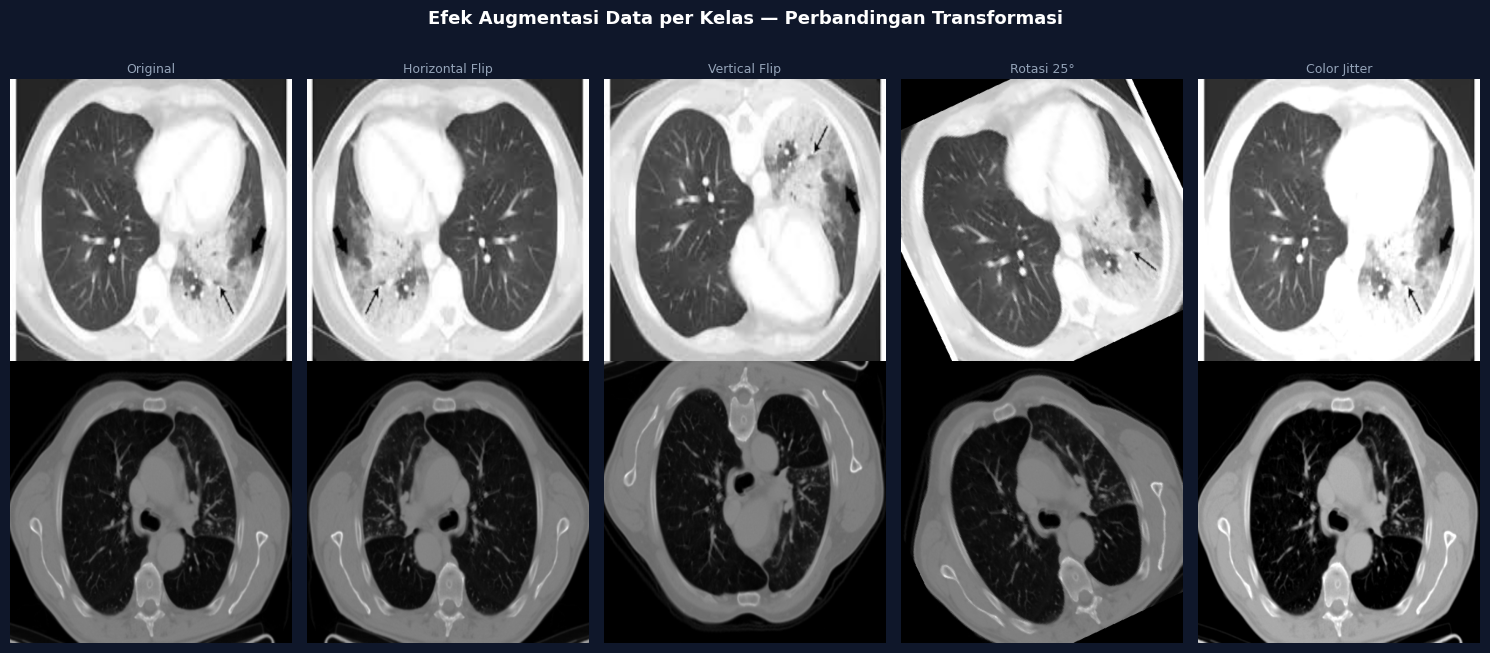

Gambar disimpan: viz_augmentation_examples.png


In [6]:
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import os, random, torch
import numpy as np

# Daftar augmentasi individual untuk divisualisasi
aug_list = [
    ("Original",             T.Compose([T.Resize(IMG_SIZE)])),
    ("Horizontal Flip",      T.Compose([T.Resize(IMG_SIZE), T.RandomHorizontalFlip(p=1.0)])),
    ("Vertical Flip",        T.Compose([T.Resize(IMG_SIZE), T.RandomVerticalFlip(p=1.0)])),
    ("Rotasi 25°",           T.Compose([T.Resize(IMG_SIZE), T.RandomRotation((25, 25))])),
    ("Color Jitter",         T.Compose([T.Resize(IMG_SIZE),
                                        T.ColorJitter(brightness=0.4, contrast=0.4)])),
]

n_aug  = len(aug_list)
n_cls  = min(2, len(CLASS_NAMES))   # tampilkan 2 kelas agar tidak terlalu panjang

fig, axes = plt.subplots(n_cls, n_aug, figsize=(n_aug * 3, n_cls * 3.2))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Efek Augmentasi Data per Kelas — Perbandingan Transformasi",
             fontsize=13, fontweight="bold", color="white", y=1.02)

for row, cls in enumerate(CLASS_NAMES[:n_cls]):
    cls_path = os.path.join(TRAIN_PATH, cls)
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    img_path = os.path.join(cls_path, random.choice(files))
    img_pil  = Image.open(img_path).convert("RGB")

    for col, (aug_name, aug_tf) in enumerate(aug_list):
        ax = axes[row][col] if n_cls > 1 else axes[col]
        aug_img = aug_tf(img_pil)
        ax.imshow(aug_img)
        ax.axis("off")
        ax.set_facecolor("#0f172a")
        if row == 0:
            ax.set_title(aug_name, fontsize=9, color="#94a3b8", pad=4)
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, color="#10b981",
                          fontweight="bold", rotation=90, labelpad=6)

plt.tight_layout()
plt.savefig("viz_augmentation_examples.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Gambar disimpan: viz_augmentation_examples.png")


# 4. Data Loading
Membuat DataLoader terpisah untuk train, val, dan test.

In [7]:
train_dataset = ImageFolder(TRAIN_PATH, transform=train_transforms)
val_dataset   = ImageFolder(VAL_PATH,   transform=eval_transforms)
test_dataset  = ImageFolder(TEST_PATH,  transform=eval_transforms)

_nw = 0 if os.name == 'nt' else 2   # num_workers=0 di Windows, 2 di Kaggle/Colab

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=_nw, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=_nw, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=_nw, pin_memory=True)

print(f"Train : {len(train_dataset)} gambar")
print(f"Val   : {len(val_dataset)} gambar")
print(f"Test  : {len(test_dataset)} gambar")
print(f"Class mapping: {train_dataset.class_to_idx}")

Train : 613 gambar
Val   : 72 gambar
Test  : 315 gambar
Class mapping: {'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 0, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 1, 'normal': 2, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 3}


# 5. Class Weights
Menghitung bobot kelas untuk menangani ketidakseimbangan data (class imbalance).

In [8]:
classes_arr = np.array(train_dataset.targets)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes_arr),
    y=classes_arr
)
class_weights_dict = dict(enumerate(class_weights_arr))
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32)

print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}


## Visualisasi 4 — Bobot Kelas (Class Weights)
Bobot dihitung untuk menangani ketidakseimbangan data. Kelas dengan sedikit sampel mendapat bobot lebih tinggi.

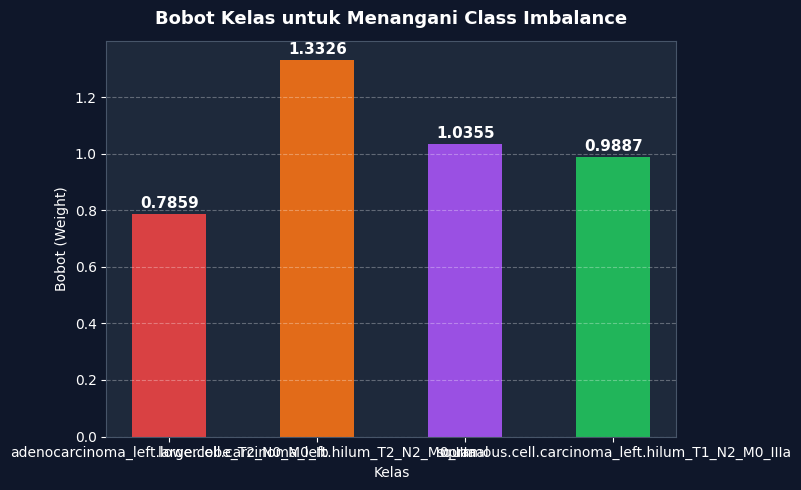

Gambar disimpan: viz_class_weights.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

weights = list(class_weights_dict.values())
colors  = ["#ef4444", "#f97316", "#a855f7", "#22c55e"][:len(CLASS_NAMES)]

bars = ax.bar(CLASS_NAMES, weights, color=colors, alpha=0.9, width=0.5)
for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{w:.4f}", ha="center", va="bottom", fontsize=11,
            fontweight="bold", color="white")

ax.set_title("Bobot Kelas untuk Menangani Class Imbalance",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Bobot (Weight)", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_class_weights.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Gambar disimpan: viz_class_weights.png")


# 6. Model Setup
Menggunakan **ResNet50** pretrained ImageNet dengan fine-tuning:
- Layer `conv4` dan `conv5` di-*unfreeze* untuk dilatih ulang pada fase 2
- Classifier head: `GlobalAvgPool → Dense(256) → BN → Dropout → Dense(128) → BN → Dropout → Output`

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Load ResNet50 pretrained
resnet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Ganti classifier head — num_classes diambil dari dataset agar selalu sinkron
num_ftrs    = resnet50.fc.in_features
num_classes = len(train_dataset.classes)
resnet50.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.4),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.3),
    nn.Linear(128, num_classes)
)

# ── FASE 1: Freeze backbone, hanya fc yang dilatih ──────────────────────
for param in resnet50.parameters():
    param.requires_grad = False
for param in resnet50.fc.parameters():
    param.requires_grad = True

resnet50 = resnet50.to(device)

total_params     = sum(p.numel() for p in resnet50.parameters())
trainable_params = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"Num classes     : {num_classes}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params (Phase 1): {trainable_params:,}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Num classes     : 4
Total params    : 24,066,756
Trainable params (Phase 1): 558,724


# 7. Training Setup — Two-Phase Transfer Learning
**Fase 1 (Head Warmup):** Hanya classifier head yang dilatih selama beberapa epoch dengan lr tinggi.
**Fase 2 (Fine-tuning):** layer3 dan layer4 di-unfreeze, seluruh model di-fine-tune dengan lr rendah.
Strategi ini mereplikasi teknik yang digunakan pada notebook original Keras untuk memperoleh akurasi optimal.

In [11]:
# Loss dengan class weights untuk mengatasi imbalance
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device),
    label_smoothing=0.1
)

def run_epoch(loader, training=True):
    if training:
        resnet50.train()
    else:
        resnet50.eval()

    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = resnet50(inputs)
            loss    = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            _, preds    = torch.max(outputs, 1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

def train_phase(phase_name, epochs, lr, patience,
                unfreeze_layers=None, checkpoint_path='best_resnet50_type.pth'):
    global train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

    # Unfreeze layer tertentu jika ada
    if unfreeze_layers:
        for name, param in resnet50.named_parameters():
            if any(layer in name for layer in unfreeze_layers):
                param.requires_grad = True
        trainable = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
        print(f"[{phase_name}] Trainable params: {trainable:,}")

    opt = optim.Adam(
        filter(lambda p: p.requires_grad, resnet50.parameters()),
        lr=lr
    )
    sch = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.2, patience=3, min_lr=1e-7
    )
    global optimizer
    optimizer = opt

    best_loss, no_improve = float('inf'), 0
    print(f"\n{'='*60}")
    print(f"  {phase_name} | lr={lr} | max_epochs={epochs} | patience={patience}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(train_loader, training=True)
        vl_loss, vl_acc = run_epoch(val_loader,   training=False)

        train_loss_hist.append(tr_loss)
        train_acc_hist.append(tr_acc)
        val_loss_hist.append(vl_loss)
        val_acc_hist.append(vl_acc)

        sch.step(vl_loss)
        curr_lr = opt.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | LR: {curr_lr:.2e}")

        if vl_loss < best_loss:
            best_loss = vl_loss
            no_improve = 0
            torch.save(resnet50.state_dict(), checkpoint_path)
            print(f"    >>> Checkpoint disimpan (val_loss={best_loss:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    --- Early stopping pada epoch {epoch+1}")
                break

    # Load bobot terbaik fase ini
    resnet50.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"\n[{phase_name}] Selesai. Best val_loss={best_loss:.4f}")

# ── Inisialisasi history ─────────────────────────────────────────────────
train_loss_hist, train_acc_hist = [], []
val_loss_hist,   val_acc_hist   = [], []
optimizer = None

# ─────────────────────────────────────────────────────────────────────────
# FASE 1: Warmup — hanya head (fc) yang dilatih, lr tinggi
# ─────────────────────────────────────────────────────────────────────────
train_phase(
    phase_name='Phase 1 — Head Warmup',
    epochs=10,
    lr=1e-3,
    patience=5,
)

# ─────────────────────────────────────────────────────────────────────────
# FASE 2: Fine-tuning — unfreeze layer3 + layer4, lr rendah
# ─────────────────────────────────────────────────────────────────────────
train_phase(
    phase_name='Phase 2 — Fine-tuning (layer3 + layer4 + fc)',
    epochs=25,
    lr=3e-5,
    patience=10,
    unfreeze_layers=['layer3', 'layer4'],
)

print("\nTraining selesai! Bobot terbaik sudah dimuat.")


  Phase 1 — Head Warmup | lr=0.001 | max_epochs=10 | patience=5
  Epoch 01/10 | Train Loss: 1.1371 Acc: 0.5073 | Val Loss: 1.2822 Acc: 0.4722 | LR: 1.00e-03
    >>> Checkpoint disimpan (val_loss=1.2822)
  Epoch 02/10 | Train Loss: 0.9929 Acc: 0.6020 | Val Loss: 1.1241 Acc: 0.3889 | LR: 1.00e-03
    >>> Checkpoint disimpan (val_loss=1.1241)
  Epoch 03/10 | Train Loss: 0.9337 Acc: 0.6444 | Val Loss: 1.0723 Acc: 0.5278 | LR: 1.00e-03
    >>> Checkpoint disimpan (val_loss=1.0723)
  Epoch 04/10 | Train Loss: 0.8502 Acc: 0.7031 | Val Loss: 1.0367 Acc: 0.6250 | LR: 1.00e-03
    >>> Checkpoint disimpan (val_loss=1.0367)
  Epoch 05/10 | Train Loss: 0.8407 Acc: 0.7015 | Val Loss: 0.9466 Acc: 0.5556 | LR: 1.00e-03
    >>> Checkpoint disimpan (val_loss=0.9466)
  Epoch 06/10 | Train Loss: 0.7888 Acc: 0.7749 | Val Loss: 0.9710 Acc: 0.6389 | LR: 1.00e-03
  Epoch 07/10 | Train Loss: 0.7884 Acc: 0.7684 | Val Loss: 0.9621 Acc: 0.6528 | LR: 1.00e-03
  Epoch 08/10 | Train Loss: 0.7199 Acc: 0.7928 | Val L

## Visualisasi 5 — Riwayat Pelatihan (Loss & Akurasi)
Grafik menampilkan kurva Loss dan Akurasi pada data latih dan validasi, dengan pembatas antar fase pelatihan.

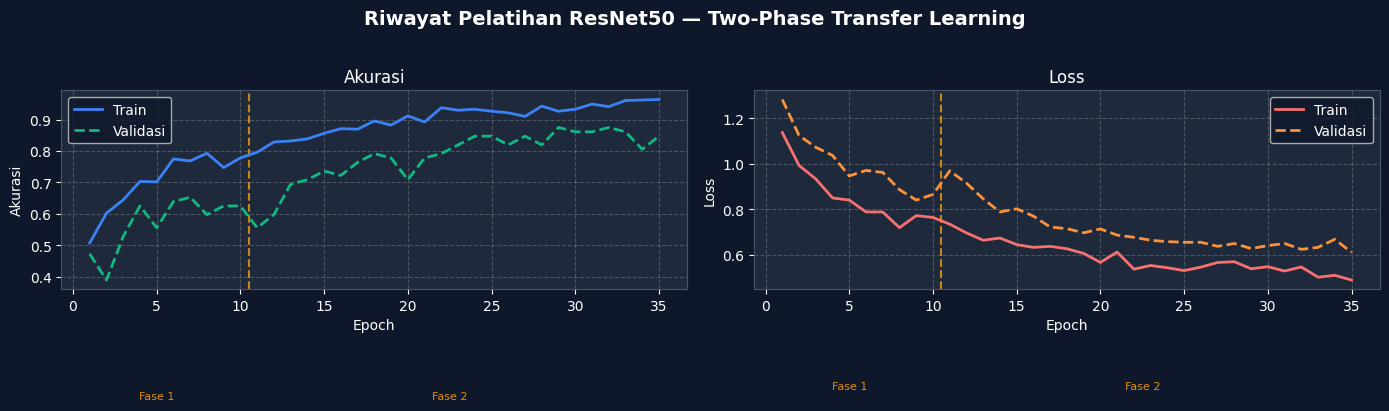

Gambar disimpan: viz_training_history.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

n_ep    = len(train_acc_hist)
epochs  = range(1, n_ep + 1)

# Hitung batas fase — Phase 1 = 10 epoch (atau sampai early stop)
# Fase 2 dimulai setelah fase 1 selesai
# Simpan panjang fase di variabel global jika tersedia, fallback ke 10
phase1_end = getattr(__builtins__, '__phase1_end__', min(10, n_ep))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Riwayat Pelatihan ResNet50 — Two-Phase Transfer Learning",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax in axes:
    ax.set_facecolor("#1e293b")
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#475569")
    ax.xaxis.grid(True, linestyle="--", alpha=0.2, color="white")
    ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")
    if phase1_end < n_ep:
        ax.axvline(x=phase1_end + 0.5, color="#f59e0b", linestyle="--",
                   linewidth=1.5, alpha=0.8)
        ax.text(phase1_end * 0.5, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else 0.01,
                "Fase 1", ha="center", fontsize=8, color="#f59e0b", alpha=0.9)
        ax.text(phase1_end + (n_ep - phase1_end) * 0.5, 0.01,
                "Fase 2", ha="center", fontsize=8, color="#f59e0b", alpha=0.9)

# Akurasi
axes[0].plot(epochs, train_acc_hist, "#3b82f6", linewidth=2, label="Train")
axes[0].plot(epochs, val_acc_hist,   "#10b981", linewidth=2, label="Validasi",
             linestyle="--")
axes[0].set_title("Akurasi", color="white", fontsize=12)
axes[0].set_xlabel("Epoch", color="white"); axes[0].set_ylabel("Akurasi", color="white")
axes[0].legend(facecolor="#0f172a", labelcolor="white")

# Loss
axes[1].plot(epochs, train_loss_hist, "#f87171", linewidth=2, label="Train")
axes[1].plot(epochs, val_loss_hist,   "#fb923c", linewidth=2, label="Validasi",
             linestyle="--")
axes[1].set_title("Loss", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white"); axes[1].set_ylabel("Loss", color="white")
axes[1].legend(facecolor="#0f172a", labelcolor="white")

plt.tight_layout()
plt.savefig("viz_training_history.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Gambar disimpan: viz_training_history.png")


# 9. Evaluasi pada Test Set
Metrik akhir dihitung pada **data test** yang belum pernah dilihat model.

In [13]:
resnet50.eval()
all_preds, all_labels = [], []
n_correct, n_total    = 0, 0

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outs  = resnet50(imgs)
        _, preds = torch.max(outs, 1)
        n_correct += (preds == lbls).sum().item()
        n_total   += lbls.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

metrics = {
    'Accuracy' : round(n_correct / n_total, 4),
    'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score   (y_true, y_pred, average='weighted', zero_division=0), 4),
    'F1 Score' : round(f1_score       (y_true, y_pred, average='weighted', zero_division=0), 4),
}

print("=== Metrik Evaluasi ResNet50 (Test Set) ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")

display(pd.DataFrame([metrics]))

=== Metrik Evaluasi ResNet50 (Test Set) ===
  Accuracy: 0.8413
  Precision: 0.8655
  Recall: 0.8413
  F1 Score: 0.8459


,Accuracy,Precision,Recall,F1 Score
0,0.8413,0.8655,0.8413,0.8459


## Visualisasi 6 — Metrik Evaluasi (Tabel & Grafik)

=== Tabel Metrik Evaluasi ===


,Accuracy,Precision,Recall,F1 Score
0,0.8413,0.8655,0.8413,0.8459


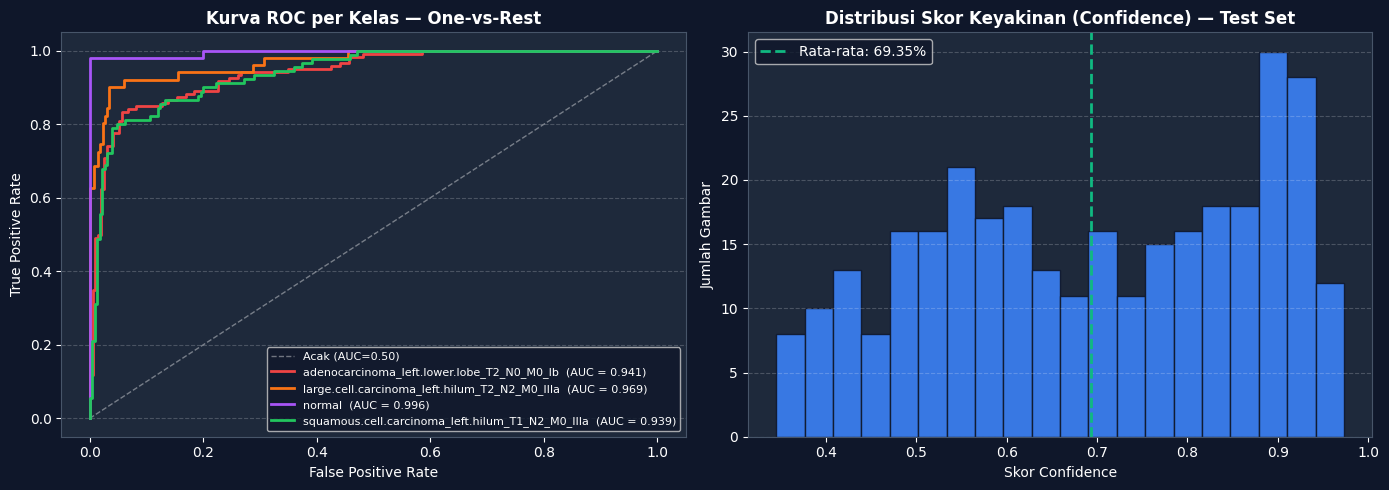

Confidence  rata-rata: 69.35%  |  max: 97.33%  |  min: 34.46%
Gambar disimpan: viz_roc_confidence.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch, torch.nn.functional as F
import numpy as np

# ── Tabel Metrik ─────────────────────────────────────────────────────────────
df_metrics = pd.DataFrame([metrics])
print("=== Tabel Metrik Evaluasi ===")
display(df_metrics.style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn", axis=1)
        .set_caption("Metrik Evaluasi ResNet50 pada Test Set"))

# ── ROC Curve ────────────────────────────────────────────────────────────────
n_cls   = len(CLASS_NAMES)
y_bin   = label_binarize(y_true, classes=list(range(n_cls)))

all_probs = []
resnet50.eval()
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs  = imgs.to(device)
        probs = F.softmax(resnet50(imgs), dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
colors_roc = ["#ef4444", "#f97316", "#a855f7", "#22c55e"]

ax = axes[0]
ax.set_facecolor("#1e293b"); ax.tick_params(colors="white")
ax.spines[:].set_color("#475569")
ax.plot([0, 1], [0, 1], "w--", linewidth=1, alpha=0.4, label="Acak (AUC=0.50)")

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls}  (AUC = {roc_auc:.3f})")

ax.set_title("Kurva ROC per Kelas — One-vs-Rest",
             color="white", fontsize=12, fontweight="bold")
ax.set_xlabel("False Positive Rate", color="white")
ax.set_ylabel("True Positive Rate", color="white")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=8, loc="lower right")
ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Distribusi Confidence ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b"); ax2.tick_params(colors="white")
ax2.spines[:].set_color("#475569")

conf_vals = np.max(all_probs, axis=1)
ax2.hist(conf_vals, bins=20, color="#3b82f6", edgecolor="#0f172a", alpha=0.9)
ax2.axvline(conf_vals.mean(), color="#10b981", linewidth=2,
            linestyle="--", label=f"Rata-rata: {conf_vals.mean():.2%}")
ax2.set_title("Distribusi Skor Keyakinan (Confidence) — Test Set",
              color="white", fontsize=12, fontweight="bold")
ax2.set_xlabel("Skor Confidence", color="white")
ax2.set_ylabel("Jumlah Gambar", color="white")
ax2.legend(facecolor="#0f172a", labelcolor="white")
ax2.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

plt.tight_layout()
plt.savefig("viz_roc_confidence.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print(f"Confidence  rata-rata: {conf_vals.mean():.2%}  |  max: {conf_vals.max():.2%}  |  min: {conf_vals.min():.2%}")
print("Gambar disimpan: viz_roc_confidence.png")


# 10. Classification Report & Confusion Matrix

Classification Report:

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.92      0.79      0.85       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.61      0.92      0.73        51
                                          normal       1.00      0.98      0.99        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.85      0.78      0.81        90

                                        accuracy                           0.84       315
                                       macro avg       0.85      0.87      0.85       315
                                    weighted avg       0.87      0.84      0.85       315



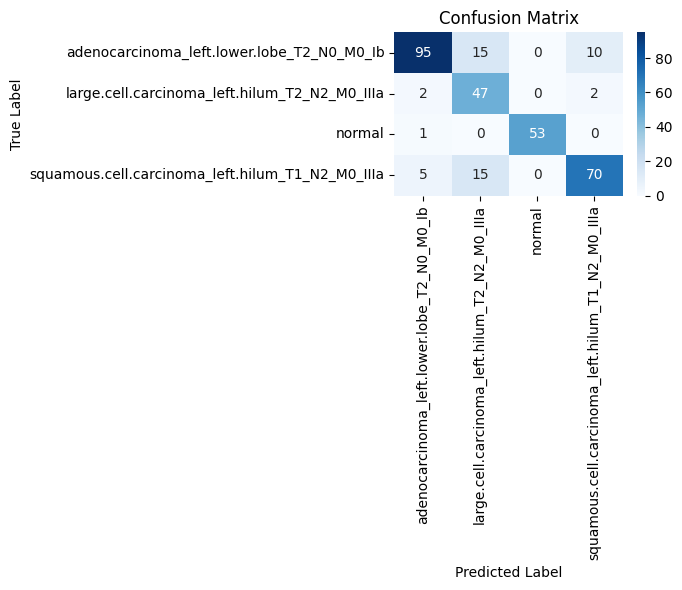

In [15]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Visualisasi 7 — Precision, Recall, F1 per Kelas
Grafik batang perbandingan tiga metrik utama untuk setiap kelas.

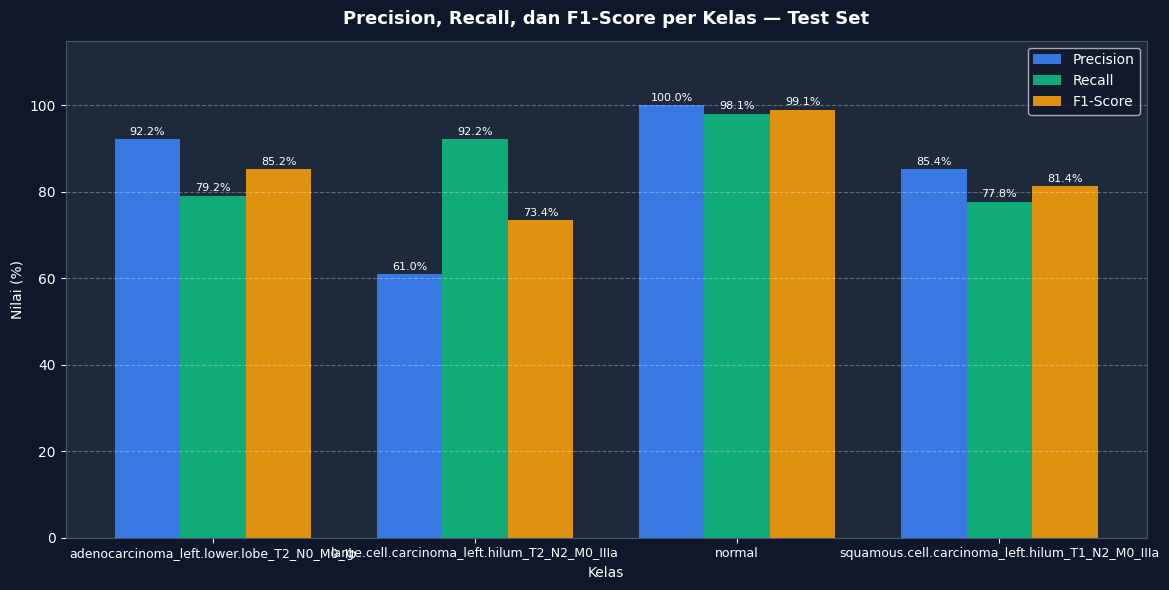

Gambar disimpan: viz_per_class_metrics.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Hitung per-class metrics
prec_per  = precision_score(y_true, y_pred, average=None, zero_division=0) * 100
rec_per   = recall_score   (y_true, y_pred, average=None, zero_division=0) * 100
f1_per    = f1_score       (y_true, y_pred, average=None, zero_division=0) * 100

x      = np.arange(len(CLASS_NAMES))
width  = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

b1 = ax.bar(x - width,     prec_per, width, label="Precision", color="#3b82f6", alpha=0.9)
b2 = ax.bar(x,             rec_per,  width, label="Recall",    color="#10b981", alpha=0.9)
b3 = ax.bar(x + width,     f1_per,   width, label="F1-Score",  color="#f59e0b", alpha=0.9)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f"{h:.1f}%", ha="center", va="bottom", fontsize=8, color="white")

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, color="white", fontsize=9)
ax.set_ylim(0, 115)
ax.set_title("Precision, Recall, dan F1-Score per Kelas — Test Set",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Nilai (%)", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")

plt.tight_layout()
plt.savefig("viz_per_class_metrics.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Gambar disimpan: viz_per_class_metrics.png")


# 11. Grad-CAM Visualization
Menampilkan heatmap Grad-CAM pada sampel gambar dari test set untuk interpretasi prediksi model.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


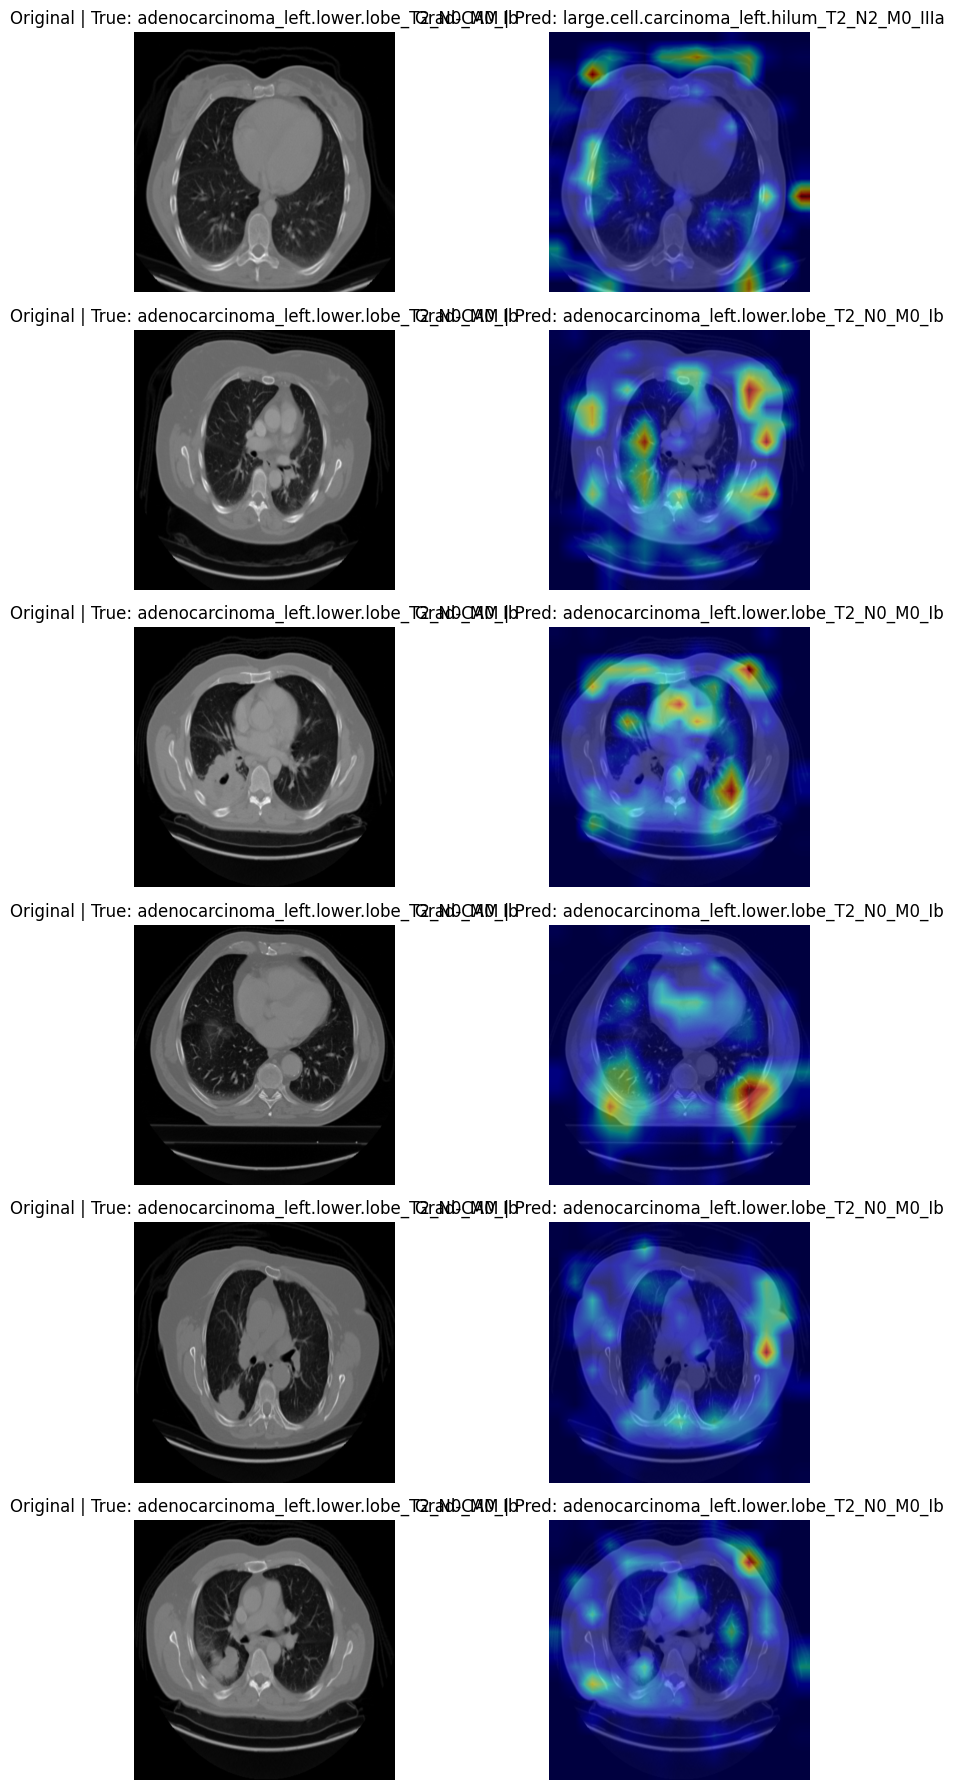

In [17]:
from torchvision.transforms.functional import to_pil_image

# ── Hook untuk Grad-CAM ──────────────────────────────────────────────────
_gradients  = {}
_activations = {}

def save_gradient(name):
    def hook(module, grad_in, grad_out):
        _gradients[name] = grad_out[0]
    return hook

def save_activation(name):
    def hook(module, input, output):
        _activations[name] = output
    return hook

# Pasang hook pada layer terakhir (layer4[-1])
target_layer = resnet50.layer4[-1]
target_layer.register_forward_hook(save_activation('layer4'))
target_layer.register_backward_hook(save_gradient('layer4'))

def generate_gradcam(img_tensor, class_idx=None):
    resnet50.eval()
    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    output = resnet50(img_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    resnet50.zero_grad()
    output[0, class_idx].backward()

    grads  = _gradients['layer4']
    acts   = _activations['layer4']

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = cam.squeeze().detach().cpu().numpy()

    # Normalize
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx

# ── Visualisasi 6 gambar ─────────────────────────────────────────────────
sample_imgs, sample_lbls = next(iter(test_loader))
n_show = min(6, len(sample_imgs))

fig, axes = plt.subplots(n_show, 2, figsize=(10, n_show * 3))

for i in range(n_show):
    img_tensor = sample_imgs[i]
    true_cls   = sample_lbls[i].item()

    cam, pred_cls = generate_gradcam(img_tensor)

    # Denormalize image untuk visualisasi
    mean = torch.tensor(resnet_mean).view(3,1,1)
    std  = torch.tensor(resnet_std).view(3,1,1)
    img_vis = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    # Resize cam ke ukuran gambar
    import cv2
    cam_resized = cv2.resize(cam, (img_vis.shape[1], img_vis.shape[0]))
    heatmap     = plt.cm.jet(cam_resized)[:, :, :3]
    overlay     = 0.5 * img_vis + 0.5 * heatmap

    axes[i, 0].imshow(img_vis)
    axes[i, 0].set_title(f"Original | True: {CLASS_NAMES[true_cls]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM | Pred: {CLASS_NAMES[pred_cls]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_59/2244033021.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/2244033021.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/2244033021.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("viz_sampel_prediksi_jenis.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
/tmp/ipykernel_59/2244033021.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("viz_sampel_prediksi_jenis.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 

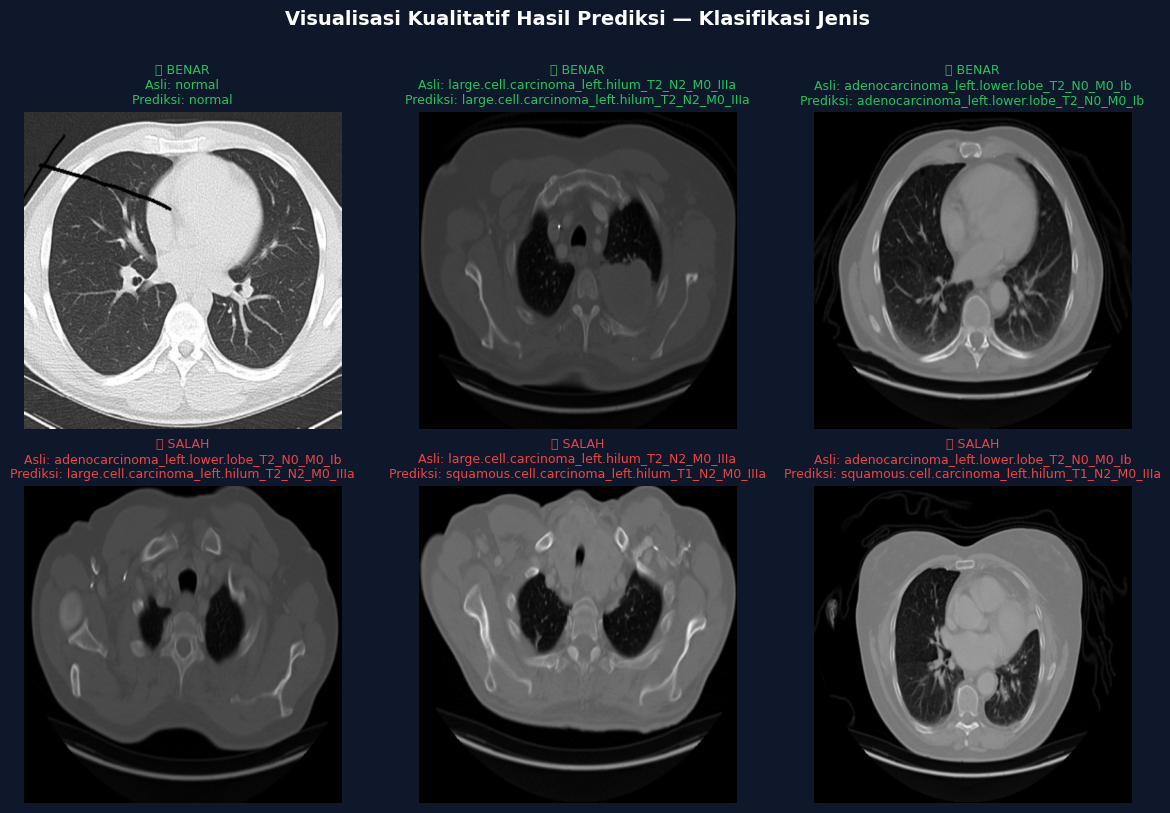

Disimpan: viz_sampel_prediksi_jenis.png


In [20]:
"""## Visualisasi — Sampel Prediksi Benar & Salah (Test Set)"""

import matplotlib.pyplot as plt
import numpy as np
import torch

def tampilkan_sampel_prediksi(loader, model, class_names, device, num_samples=3):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    all_imgs, all_true, all_pred = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            outs = model(imgs.to(device))
            _, preds = torch.max(outs, 1)
            all_imgs.extend(imgs.cpu())
            all_true.extend(lbls.numpy())
            all_pred.extend(preds.cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    benar_idx = np.where(all_true == all_pred)[0]
    salah_idx = np.where(all_true != all_pred)[0]

    sampel_benar = np.random.choice(benar_idx, min(num_samples, len(benar_idx)), replace=False)
    sampel_salah = np.random.choice(salah_idx, min(num_samples, len(salah_idx)), replace=False)

    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 4, 8))
    fig.patch.set_facecolor("#0f172a")
    fig.suptitle("Visualisasi Kualitatif Hasil Prediksi — Klasifikasi Jenis",
                 fontsize=14, fontweight="bold", color="white", y=1.01)

    for i, idx in enumerate(sampel_benar):
        img = (all_imgs[idx] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax = axes[0, i]
        ax.imshow(img); ax.axis("off")
        ax.set_facecolor("#0f172a")
        ax.set_title(f"✅ BENAR\nAsli: {class_names[all_true[idx]]}\nPrediksi: {class_names[all_pred[idx]]}",
                     color="#22c55e", fontsize=9)

    for i, idx in enumerate(sampel_salah):
        img = (all_imgs[idx] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax = axes[1, i]
        ax.imshow(img); ax.axis("off")
        ax.set_facecolor("#0f172a")
        ax.set_title(f"❌ SALAH\nAsli: {class_names[all_true[idx]]}\nPrediksi: {class_names[all_pred[idx]]}",
                     color="#ef4444", fontsize=9)

    plt.tight_layout()
    plt.savefig("viz_sampel_prediksi_jenis.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
    plt.show()
    print("Disimpan: viz_sampel_prediksi_jenis.png")

# Jalankan — CLASS_NAMES sudah ada dari cell sebelumnya
tampilkan_sampel_prediksi(test_loader, resnet50, CLASS_NAMES, device, num_samples=3)


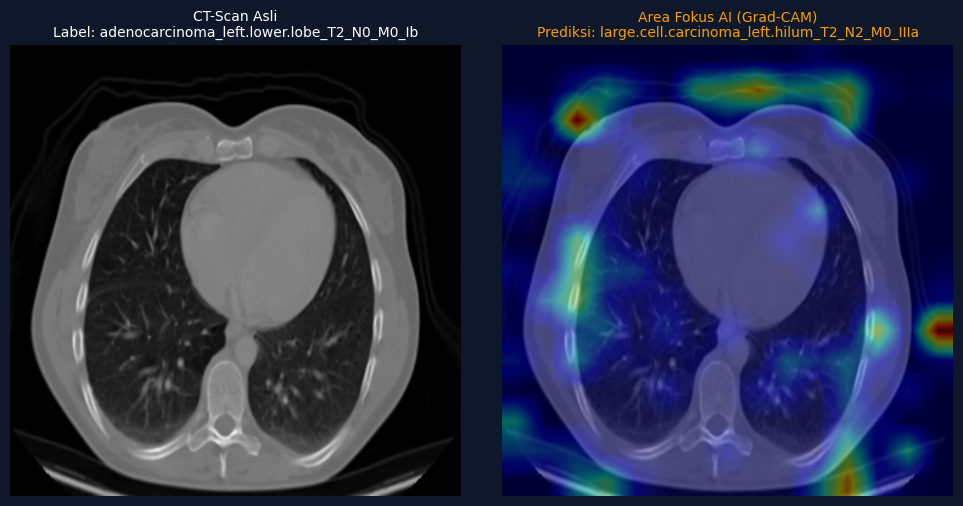

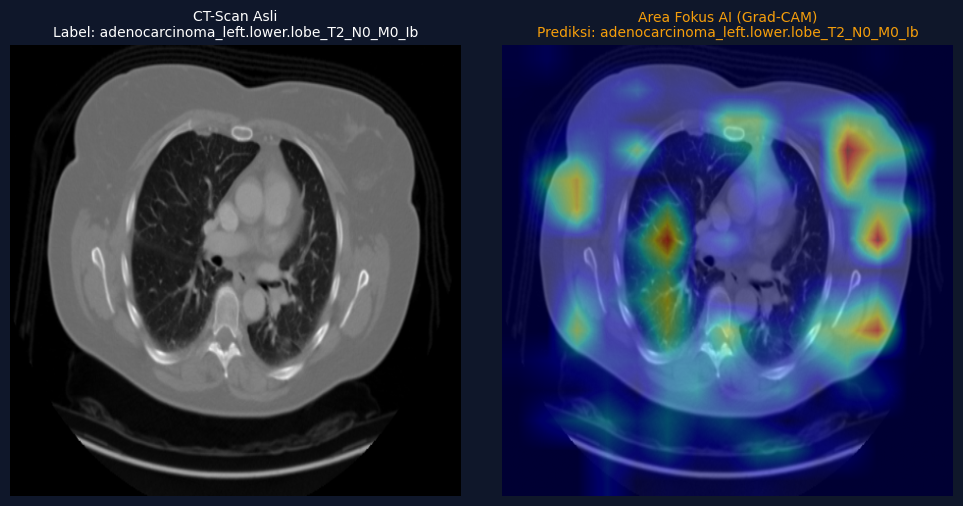

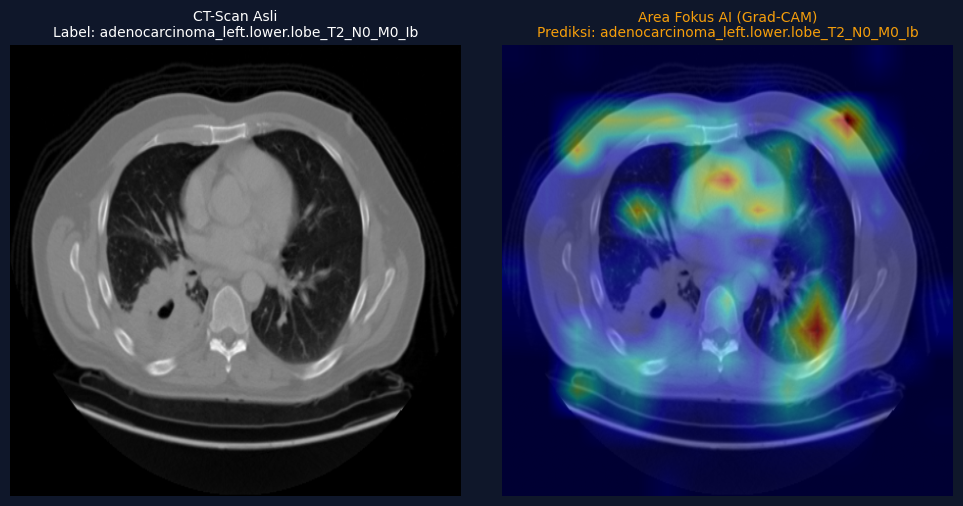

In [21]:
"""## Grad-CAM — Klasifikasi Jenis Kanker"""

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

_grads, _acts = {}, {}

def hook_grad(m, gi, go):  _grads['l4'] = go[0]
def hook_act(m, i, o):     _acts['l4']  = o

h1 = resnet50.layer4[-1].register_forward_hook(hook_act)
h2 = resnet50.layer4[-1].register_backward_hook(hook_grad)

def buat_heatmap_gradcam(img_tensor, model, pred_index=None):
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)
    x.requires_grad_(True)
    out = model(x)
    if pred_index is None:
        pred_index = out.argmax(dim=1).item()
    model.zero_grad()
    out[0, pred_index].backward()
    weights = _grads['l4'].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * _acts['l4']).sum(dim=1)).squeeze()
    cam = cam.detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, pred_index

def tampilkan_gradcam(img_tensor, cam, true_label, pred_label, alpha=0.4):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = (img_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()

    cam_r   = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = plt.cm.jet(cam_r)[:, :, :3]
    overlay = (alpha * heatmap + (1 - alpha) * img).clip(0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.patch.set_facecolor("#0f172a")
    axes[0].imshow(img);     axes[0].axis("off")
    axes[1].imshow(overlay); axes[1].axis("off")
    axes[0].set_title(f"CT-Scan Asli\nLabel: {true_label}",  color="white", fontsize=10)
    axes[1].set_title(f"Area Fokus AI (Grad-CAM)\nPrediksi: {pred_label}", color="#f59e0b", fontsize=10)
    plt.tight_layout()
    plt.savefig("viz_gradcam_jenis.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
    plt.show()

# Eksekusi — ambil beberapa sampel dari test_loader
sample_imgs, sample_lbls = next(iter(test_loader))
for i in range(min(3, len(sample_imgs))):
    cam, pred_idx = buat_heatmap_gradcam(sample_imgs[i], resnet50)
    tampilkan_gradcam(
        sample_imgs[i],
        cam,
        true_label  = CLASS_NAMES[sample_lbls[i].item()],
        pred_label  = CLASS_NAMES[pred_idx]
    )

h1.remove(); h2.remove()  # bersihkan hooks


# 12. Save Model
Simpan model ke format `.pth` (state dict), `.h5` (full model via ONNX), TorchScript, dan ONNX.

In [19]:
import shutil
# State-dict (bobot terbaik sudah di-load)
shutil.copy('best_resnet50_type.pth', 'final_lung_cancer_type_model.pth')
print("Saved: final_lung_cancer_type_model.pth")

# TorchScript
example = torch.rand(1, 3, 460, 460).to(device)
resnet50.eval()
script  = torch.jit.trace(resnet50, example)
script.save('lung_cancer_type_production.pt')
print("Saved: lung_cancer_type_production.pt")

# ONNX
torch.onnx.export(
    resnet50, example, 'lung_cancer_type_model.onnx',
    export_params=True, opset_version=18,
    do_constant_folding=True,
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Saved: lung_cancer_type_model.onnx")

print("\nSemua model berhasil disimpan!")

Saved: final_lung_cancer_type_model.pth


ValueError: Modules that have backward hooks assigned can't be compiled: Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)